### Importing Required Libraries

In [2]:
import csv
import matplotlib.pyplot as plt

### Making Reuseable Functions

In [3]:
def get_median(values):
    sorted_vals = sorted(values)
    n = len(sorted_vals)
    mid = n // 2
    if n % 2 == 1:
        return sorted_vals[mid]
    return round((sorted_vals[mid - 1] + sorted_vals[mid]) / 2)


def print_dynamic_table(dataset, spacing=3):
    if not dataset:
        print("No data available to print.")
        return

    col_widths = {
        key: max(
            len(str(key)),
            max(
                len(f"{row[key]:.2f}" if isinstance(row[key], float) else str(row[key]))
                for row in dataset
            ),
        )
        for key in dataset[0].keys()
    }

    col_spacing = " " * spacing

    print(col_spacing.join(
        f"{str(key).upper().replace('_', ' '):<{col_widths[key]}}"
        for key in dataset[0].keys()
    ))

    for row in dataset:
        print(col_spacing.join(
            f"{f'{row[key]:.2f}' if isinstance(row[key], float) else str(row[key]):<{col_widths[key]}}"
            for key in dataset[0].keys()
        ))

### Loading Raw Data From CSV File

In [13]:
# Load raw data
raw_data = []

with open('weekly_growth.csv', mode='r', newline='', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    field_names = reader.fieldnames
    for row in reader:
        raw_data.append(row)

print("=== Raw Data ===")
print_dynamic_table(raw_data)
print(f"\nTotal Records: {len(raw_data)}")

=== Raw Data ===
WEEK       REGION   SIGNUPS   ACTIVE USERS   PAID SUBSCRIPTIONS   REVENUE   SUPPORT TICKETS
2025-W01   North    120       410            24                   2400      18             
2025-W01   South    95        360            19                   1900      15             
2025-W02   north    130       430            27                   2700      20             
2025-W02   South    102       372            18                   1800      17             
2025-W03   East     88        300            14                   1400      14             
2025-W03   West     110       395            25                   2500      19             
2025-W04   East     92        315            16                   1600      16             
2025-W04   West     118       402            24                   2400      35             
2025-W05   North    140       455            31                   3100      21             
2025-W05   South    108       380            20                

**Data Quality Issues Identified**:
  1. Inconsistent casing: row 3 has region 'north' instead of 'North'
  2. Missing value: row 10 has an empty support_tickets field
  3. Exact duplicate: rows 12 and 13 are identical (2025-W06, West)

### Cleaned Data After Processing

In [6]:
# Task 1: Remove duplicates
seen = set()
cleaned_data = []

for row in raw_data:
    row_key = frozenset(row.items())
    if row_key not in seen:
        seen.add(row_key)
        cleaned_data.append(row)

# Task 2 & 3: Standardize region casing and convert numeric fields
for record in cleaned_data:
    record['region'] = record['region'].title()
    record['signups'] = int(record['signups'])
    record['active_users'] = int(record['active_users'])
    record['paid_subscriptions'] = int(record['paid_subscriptions'])
    record['revenue'] = int(record['revenue'])
    if record['support_tickets'] != '':
        record['support_tickets'] = int(record['support_tickets'])

# Task 4: Fill missing support_tickets with median
ticket_values = [r['support_tickets'] for r in cleaned_data if r['support_tickets'] != '']
median_tickets = get_median(ticket_values)

for record in cleaned_data:
    if record['support_tickets'] == '':
        record['support_tickets'] = median_tickets

# Task 5: Add conversion_rate
for record in cleaned_data:
    record['conversion_rate'] = round(record['paid_subscriptions'] / record['signups'] * 100, 1)

print("=== Cleaned Data ===")
print_dynamic_table(cleaned_data)
print(f"\nTotal Records After Cleaning: {len(cleaned_data)}")

=== Cleaned Data ===
WEEK       REGION   SIGNUPS   ACTIVE USERS   PAID SUBSCRIPTIONS   REVENUE   SUPPORT TICKETS   CONVERSION RATE
2025-W01   North    120       410            24                   2400      18                20.00          
2025-W01   South    95        360            19                   1900      15                20.00          
2025-W02   North    130       430            27                   2700      20                20.80          
2025-W02   South    102       372            18                   1800      17                17.60          
2025-W03   East     88        300            14                   1400      14                15.90          
2025-W03   West     110       395            25                   2500      19                22.70          
2025-W04   East     92        315            16                   1600      16                17.40          
2025-W04   West     118       402            24                   2400      35                20.30

### Revenue Summary

In [14]:
total_revenue = 0
revenue_by_region = {}
revenue_by_week = {}
conversion_rates = []

for record in cleaned_data:
    total_revenue += record['revenue']

    key_region = record['region']
    if key_region not in revenue_by_region:
        revenue_by_region[key_region] = 0
    revenue_by_region[key_region] += record['revenue']

    key_week = record['week']
    if key_week not in revenue_by_week:
        revenue_by_week[key_week] = 0
    revenue_by_week[key_week] += record['revenue']

top_region = max(revenue_by_region, key=lambda r: revenue_by_region[r])
top_week = max(revenue_by_week, key=lambda w: revenue_by_week[w])
avg_conversion_rate = round(sum(r['conversion_rate'] for r in cleaned_data) / len(cleaned_data), 1)

print(f"""
Total Revenue             : ${total_revenue:,}
Highest Revenue Region    : {top_region} (Total Revenue = ${revenue_by_region[top_region]:,})
Highest Revenue Week      : {top_week} (Total Revenue = ${revenue_by_week[top_week]:,})
Avg Conversion Rate       : {avg_conversion_rate}%
""")


Total Revenue             : $26,100
Highest Revenue Region    : North (Total Revenue = $8,200)
Highest Revenue Week      : 2025-W05 (Total Revenue = $5,100)
Avg Conversion Rate       : 19.5%



### EDA Analysis

In [15]:
# Weekly revenue trend
print("Revenue by Week:")
print(f"   {'Week':<12}{'Revenue'}")
print(f"   {'-'*22}")
for week in sorted(revenue_by_week):
    print(f"   {week:<12}${revenue_by_week[week]:,}")

# Record with highest support tickets
highest_support = max(cleaned_data, key=lambda r: r['support_tickets'])

print("\nRecord With Highest Support Tickets:")
for key, value in highest_support.items():
    print(f"   {key:<25}: {value}")

# Outlier observation
print("""
Outlier Note:
   The record for 2025-W04 West shows 35 support tickets.
   All other records range between 14 and 21 tickets.
   This value is significantly higher than the rest of the dataset
   and likely represents an isolated issue that week in the West region.
   It warrants further investigation — for example, a platform outage
   or a course launch that generated unusually high user friction.
""")

Revenue by Week:
   Week        Revenue
   ----------------------
   2025-W01    $4,300
   2025-W02    $4,500
   2025-W03    $3,900
   2025-W04    $4,000
   2025-W05    $5,100
   2025-W06    $4,300

Record With Highest Support Tickets:
   week                     : 2025-W04
   region                   : West
   signups                  : 118
   active_users             : 402
   paid_subscriptions       : 24
   revenue                  : 2400
   support_tickets          : 35
   conversion_rate          : 20.3

Outlier Note:
   The record for 2025-W04 West shows 35 support tickets.
   All other records range between 14 and 21 tickets.
   This value is significantly higher than the rest of the dataset
   and likely represents an isolated issue that week in the West region.
   It warrants further investigation — for example, a platform outage
   or a course launch that generated unusually high user friction.



# Reports

### PRODUCT ANALYTICS TECHNICAL REPORT: USER ENGAGEMENT & REVENUE PERFORMANCE

#### 1. OBJECTIVE
The objective of this analysis was to process, clean, and evaluate the raw regional performance dataset for the first six weeks of 2025. The goal was to establish baseline product metrics, identify weekly regional revenue trends, and pinpoint anomalies to guide future product and engineering resource allocations.

#### 2. DATA PREPARATION
Three distinct data quality issues were identified and resolved in the raw dataset containing `13` initial records. First, inconsistent casing for the '`north`' region in row 3 was standardized to title case ('`North`'). Second, a missing value in the support tickets field for `2025-W05` (South) was handled via median imputation, substituting the missing field with 18 tickets. Third, an exact duplicate record for `2025-W06` (West) was removed via deduplication, resulting in a finalized dataset of 12 clean records.

#### 3. KEY METRICS
The data pipeline yielded four foundational metrics across the consolidated six-week period. Total aggregate revenue reached `$26,100`, driven heavily by the North, which emerged as the highest-revenue region with a total of `$8,200`. Performance peaked during `2025-W05`, which was identified as the highest-revenue week with `$5,100` generated. Across all regions and weeks, the portfolio maintained an average signup-to-subscription conversion rate of `19.5%`.

#### 4. EDA NOTES
Exploratory data analysis revealed a fluctuating weekly revenue trend that dipped to a low of `$3,900` in `2025-W03` before spiking to its `$5,100` peak in `2025-W05`. Additionally, a significant operational outlier was detected in week `2025-W04` within the West region, which logged `35` support tickets. Because all other data points strictly range between `14` and `21` tickets, this volume represents a severe deviation from baseline friction levels.

#### 5. RECOMMENDATION
It is recommended that the product team initiate a cross-functional retro with the engineering and customer support teams specifically to audit the `2025-W04` system logs for the West region. Because active users (`402`) and conversion rates (`20.3%`) remained stable that week, we must investigate whether an isolated infrastructure outage, localized bug, or specific regional payment gateway failure triggered this localized surge in user friction.

### EXECUTIVE BRIEFING: USER ENGAGEMENT & REVENUE PERFORMANCE

#### 1. OVERVIEW
We conducted a comprehensive review of our regional sales and user data across the first six weeks of 2025 to evaluate growth, check data health, and find opportunities to scale our revenue. Before running the numbers, we cleaned up the dataset by removing accidental duplicate entries and filling in a few missing data points to ensure the insights are completely accurate.

#### 2. THE BIG PICTURE
Our platform generated `$26,100` in total revenue during this six-week window, proving strong initial traction for the year. Performance peaked dramatically in the fifth week (2025-W05), bringing in `$5,100` in a single seven-day period.

#### 3. WHERE WE ARE WINNING
The North region is our undisputed growth engine, contributing `$8,200`—nearly a third of our total company revenue. Across all territories, an average of roughly 1 in 5 users who signed up ultimately decided to upgrade to a paid subscription, showing healthy commercial interest.

#### 4. AREAS FOR ATTENTION
While the West region is a strong performer, it experienced a massive spike of 35 customer support tickets during the fourth week (2025-W04)—nearly double its usual average. Because sales and active users remained steady that week, this isolated roadblock points to a temporary regional glitch rather than a drop-off in customer interest.

#### 5. IMMEDIATE NEXT STEPS
We are coordinating a brief review between our customer support and engineering teams to audit the week 4 support logs in the West. Identifying and fixing whatever caused that friction will ensure we protect customer satisfaction and prevent revenue loss during future traffic surges.

#### 6. RECOMMENDED PRESENTATION VISUALS
* Visual 1: A regional revenue comparison bar chart to visually highlight the North's market dominance and compare it clearly against the South, East, and West.

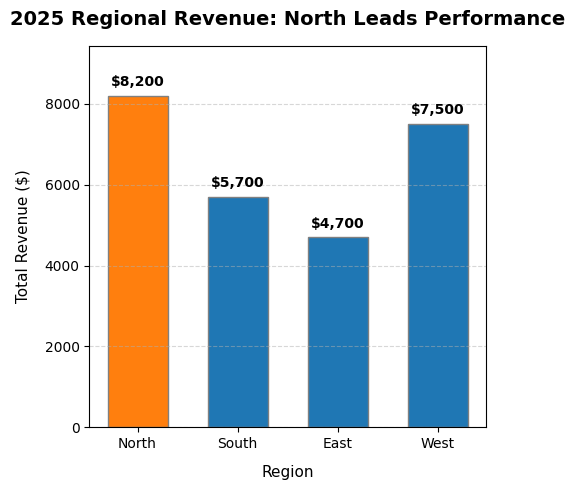

In [21]:
plt.figure(figsize=(5, 5))

# Extract regions and values directly from your pre-calculated dictionary
regions = list(revenue_by_region.keys())
regional_revenue = list(revenue_by_region.values())

# Highlight the top region dynamically using your 'top_region' variable
colors = ['#ff7f0e' if r == top_region else '#1f77b4' for r in regions]

bars = plt.bar(regions, regional_revenue, color=colors, edgecolor='grey', width=0.6)

# Formatting for presentation clarity
plt.title(f'2025 Regional Revenue: {top_region} Leads Performance', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=11, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of each bar dynamically
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(regional_revenue) * 0.02), f"${yval:,}", ha='center', va='bottom', fontweight='bold')

# Automatically adjust bounds to fit the labels nicely
plt.ylim(0, max(regional_revenue) * 1.15)
plt.tight_layout()
plt.savefig('regional_revenue_comparison.png', dpi=300)
plt.show()

* Visual 2: A weekly revenue trend line chart to illustrate the journey from the week 3 dip up to the week 5 peak, providing a clear picture of our operational momentum.

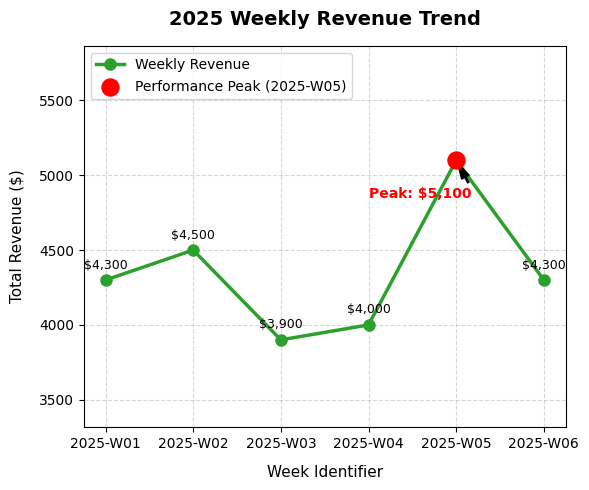

In [22]:
plt.figure(figsize=(6, 5))

# Sort weeks chronologically directly from your pre-calculated dictionary
sorted_weeks = sorted(revenue_by_week.keys())
weekly_revenue = [revenue_by_week[w] for w in sorted_weeks]

plt.plot(sorted_weeks, weekly_revenue, marker='o', color='#2ca02c', linewidth=2.5, markersize=8, label='Weekly Revenue')

# Dynamically highlight the peak using your 'top_week' variable
peak_value = revenue_by_week[top_week]
plt.scatter(top_week, peak_value, color='red', s=150, zorder=5, label=f'Performance Peak ({top_week})')

# Text annotation for the peak value
plt.annotate(
    f'Peak: ${peak_value:,}',
    xy=(top_week, peak_value),
    xytext=(sorted_weeks[max(0, sorted_weeks.index(top_week)-1)], peak_value - (max(weekly_revenue)*0.05)),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontweight='bold',
    color='red'
)

# Formatting for presentation clarity
plt.title('2025 Weekly Revenue Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Week Identifier', fontsize=11, labelpad=10)
plt.ylabel('Total Revenue ($)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

# Add data point labels to line vertices dynamically
for i, txt in enumerate(weekly_revenue):
    if sorted_weeks[i] != top_week:  # Skip top_week to avoid overlap with the main annotation
        plt.text(sorted_weeks[i], weekly_revenue[i] + (max(weekly_revenue) * 0.015), f"${txt:,}", ha='center', fontsize=9)

# Adjust bounds to leave breathing room for text labels
plt.ylim(min(weekly_revenue) * 0.85, max(weekly_revenue) * 1.15)
plt.tight_layout()
plt.savefig('weekly_revenue_trend.png', dpi=300)
plt.show()